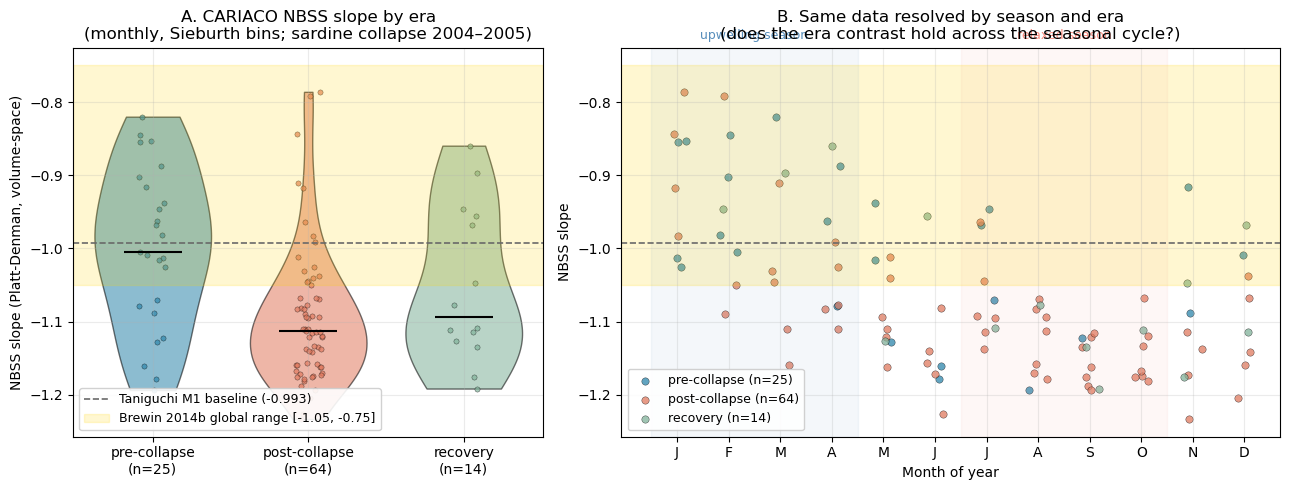

Era medians:
               count  median   mean
era                                
post-collapse     64  -1.113 -1.094
pre-collapse      25  -1.005 -0.999
recovery          14  -1.093 -1.051


In [1]:
# CELL A — Cariaco NBSS slope: era distribution + per-month seasonal pattern
# Run from code/ directory (so the CSV relative path resolves), or set CSV_PATH explicitly.

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Path mirrors cariaco_obs.DEFAULT_CSV_PATH (../data/processed/...).
# If your notebook lives elsewhere, set CSV_PATH manually.
CSV_PATH = os.path.join('..', 'data', 'processed', 'cariaco_monthly_euphotic_dynamic.csv')
import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

df = pd.read_csv(CSV_PATH, parse_dates=['date'])
df = df.dropna(subset=['nbss_slope']).copy()
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

# Era definitions match project_obs_envelope.md
def assign_era(year):
    if year < 2005:   return 'pre-collapse'
    if year < 2014:   return 'post-collapse'
    return 'recovery'

df['era'] = df['year'].apply(assign_era)
era_order  = ['pre-collapse', 'post-collapse', 'recovery']
era_colors = {'pre-collapse': '#2E86AB', 'post-collapse': '#E07A5F', 'recovery': '#81B29A'}

# Reference anchors (per Taniguchi_Model1_Baseline.tex and project_obs_envelope.md)
TANIGUCHI_BASELINE = -0.993
BREWIN_LOW, BREWIN_HIGH = -1.05, -0.75

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.0), gridspec_kw={'width_ratios': [1, 1.4]})

# ---------- LEFT PANEL: era violins ----------
data_by_era = [df.loc[df['era'] == e, 'nbss_slope'].values for e in era_order]
parts = axL.violinplot(data_by_era, positions=range(len(era_order)),
                       showmedians=True, showextrema=False, widths=0.75)
for body, era in zip(parts['bodies'], era_order):
    body.set_facecolor(era_colors[era]); body.set_edgecolor('black'); body.set_alpha(0.55)
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(1.5)

# Per-month jitter overlay so the supervisor sees the n
rng = np.random.default_rng(0)
for i, e in enumerate(era_order):
    y = df.loc[df['era'] == e, 'nbss_slope'].values
    x = i + (rng.random(len(y)) - 0.5) * 0.18
    axL.scatter(x, y, s=14, color=era_colors[e], edgecolor='black', linewidth=0.3, alpha=0.7)

axL.axhline(TANIGUCHI_BASELINE, color='dimgray', ls='--', lw=1.2,
            label=f'Taniguchi M1 baseline ({TANIGUCHI_BASELINE:.3f})')
axL.axhspan(BREWIN_LOW, BREWIN_HIGH, color='gold', alpha=0.18,
            label=f'Brewin 2014b global range [{BREWIN_LOW:.2f}, {BREWIN_HIGH:.2f}]')
axL.set_xticks(range(len(era_order)))
axL.set_xticklabels([f'{e}\n(n={len(d)})' for e, d in zip(era_order, data_by_era)])
axL.set_ylabel('NBSS slope (Platt-Denman, volume-space)')
axL.set_title('A. CARIACO NBSS slope by era\n(monthly, Sieburth bins; sardine collapse 2004–2005)')
axL.legend(loc='lower left', fontsize=9, framealpha=0.9)
axL.grid(alpha=0.25)

# ---------- RIGHT PANEL: per-month seasonal scatter ----------
for e in era_order:
    sub = df[df['era'] == e]
    axR.scatter(sub['month'] + rng.uniform(-0.18, 0.18, len(sub)),
                sub['nbss_slope'],
                s=28, color=era_colors[e], edgecolor='black', linewidth=0.3,
                alpha=0.75, label=f'{e} (n={len(sub)})')

axR.axhline(TANIGUCHI_BASELINE, color='dimgray', ls='--', lw=1.2)
axR.axhspan(BREWIN_LOW, BREWIN_HIGH, color='gold', alpha=0.18)

# Annotate upwelling vs relaxed season for Cariaco (DJF / JF cool upwelling; JJA warm relaxed)
axR.axvspan(0.5, 4.5, color='steelblue', alpha=0.06)  # upwelling-favoured months
axR.axvspan(6.5, 10.5, color='salmon',   alpha=0.06)  # relaxed-favoured months
axR.text(2.5, axR.get_ylim()[1] if False else -0.7, 'upwelling season',
         ha='center', va='top', fontsize=9, color='steelblue', alpha=0.9)
axR.text(8.5, -0.7, 'relaxed season',
         ha='center', va='top', fontsize=9, color='salmon', alpha=0.9)

axR.set_xticks(range(1, 13))
axR.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axR.set_xlabel('Month of year')
axR.set_ylabel('NBSS slope')
axR.set_title('B. Same data resolved by season and era\n(does the era contrast hold across the seasonal cycle?)')
axR.legend(loc='lower left', fontsize=9, framealpha=0.9)
axR.grid(alpha=0.25)

# Match y-axis ranges
y_all_lo = min(axL.get_ylim()[0], axR.get_ylim()[0])
y_all_hi = max(axL.get_ylim()[1], axR.get_ylim()[1])
axL.set_ylim(y_all_lo, y_all_hi); axR.set_ylim(y_all_lo, y_all_hi)

plt.tight_layout()
#plt.savefig('fig_obs_nbss_era_season.png', dpi=160, bbox_inches='tight')
plt.show()

# Quick summary printout for sanity / supervisor talking points
print('Era medians:')
print(df.groupby('era')['nbss_slope'].agg(['count', 'median', 'mean']).round(3))

In [ ]:
# CELL B v3 — fish grazing via the existing MS3-as-built kernel component.
# Imports cariaco_ssm_comps.FishGrazing_Kernel + ConstantFishForcing
# and cariaco_ssm_setup.compute_fish_kernel_vdl_joint.

import numpy as np
import xso
import np_setups as nps
from np_comps import (Nutrient, PhytoSizeSpectrum, ZooSizeSpectrum,
                       MonodGrowth_NP, PhytoLinearLoss_recycled,
                       ZooQuadraticLoss_recycled,
                       GrazingMatrix_TypeIII, GrazingRouter,
                       ConstantExternalNutrient, LinearForcingInput,
                       ChemostatDilution_Scalar, ChemostatDilution_PhytoDim,
                       ChemostatDilution_ZooDim)
from cariaco_ssm_comps import FishGrazing_Kernel, ConstantFishForcing
from cariaco_ssm_setup import compute_fish_kernel_vdl_joint

RK45_KWARGS = {'method': 'RK45', 'atol': 1e-6, 'rtol': 1e-4,
               'instability_neg_threshold': -1e-3}
# In both setups, replace solver_kwargs=nps.IVP_SOLVER_KWARGS with solver_kwargs=RK45_KWARGS

# Compute the Rykaczewski (2019) clearance-rate kernel on the np_setups grids.
# Joint peak-normalisation: K(s) = 1 at preferred prey size (~1230 µm),
# decaying away on both grids. rate · fish_biomass = absolute peak rate.
kernel_P_fish, kernel_Z_fish = compute_fish_kernel_vdl_joint(nps.phyto_esd,
                                                              nps.zoo_esd)
print(f'kernel_P range: [{kernel_P_fish.min():.3e}, {kernel_P_fish.max():.3e}]')
print(f'kernel_Z range: [{kernel_Z_fish.min():.3e}, {kernel_Z_fish.max():.3e}]')
print(f'Z class at kernel_Z peak: {nps.zoo_esd[kernel_Z_fish.argmax()]:.1f} µm')

# Fish-rate parameters. MS3-as-built default is rate=0.005, F=1.0 → 0.005 d-1
# peak grazing. That's a fairly gentle top-down term; for a visible demo we
# can push it 10–20x (still within the literature-uncertain "no constraint"
# space per `Current Status Briefing.md`).
fish_biomass = 1.0
fish_rate    = 0.05      # bump from 0.005 default to make the response clear

model_npz_typeIII_omni_fish = xso.create({
    'Nutrient':      Nutrient,
    'Phytoplankton': PhytoSizeSpectrum,
    'Zooplankton':   ZooSizeSpectrum,
    'Growth':        MonodGrowth_NP,
    'PhytoLoss':     PhytoLinearLoss_recycled,
    'ZooLoss':       ZooQuadraticLoss_recycled,
    'Grazing':       GrazingMatrix_TypeIII,
    'GrazingRouter': GrazingRouter,
    'FishForcing':   ConstantFishForcing,        # NEW
    'FishGrazing':   FishGrazing_Kernel,         # NEW (acts on BOTH P and Z)
    'FN_Forcing':    ConstantExternalNutrient,
    'FN_Input':      LinearForcingInput,
    'DilutionN':     ChemostatDilution_Scalar,
    'DilutionP':     ChemostatDilution_PhytoDim,
    'DilutionZ':     ChemostatDilution_ZooDim,
})

model_setup_npz_typeIII_omni_fish = xso.setup(
    solver='solve_ivp', model=model_npz_typeIII_omni_fish,
    time=nps.ivp_time_array,
    input_vars={
        'Nutrient':      {'value_label': 'N', 'value_init': nps.N_INIT_OPEN},
        'Phytoplankton': {'biomass_label': 'P', 'biomass_init': nps.phyto_init,
                          'phyto_esd_index': nps.phyto_esd.tolist(),
                          'phyto_esd_label': 'phyto_esd'},
        'Zooplankton':   {'biomass_label': 'Z', 'biomass_init': nps.zoo_init,
                          'zoo_esd_index': nps.zoo_esd.tolist(),
                          'zoo_esd_label': 'zoo_esd'},
        'Growth':        {'resource': 'N', 'consumer': 'P',
                          'mu_max': nps.mu_max_arr, 'halfsat': nps.k_s_arr},
        'PhytoLoss':     {'population': 'P', 'nutrient': 'N',
                          'rate': nps.lambda_arr_const},
        'ZooLoss':       {'population': 'Z', 'nutrient': 'N',
                          'rate': nps.M_Z_VAL},
        'Grazing':       {'resource': 'P', 'consumer': 'Z',
                          'phiPZ': nps.phiPZ_omni,
                          'Imax': nps.Imax_arr, 'KsZ': nps.KSZ_VAL},
        'GrazingRouter': {'grazed_phyto': 'P', 'grazed_zoo': 'Z',
                          'assimilated_consumer': 'Z',
                          'excreted_nutrient': 'N',
                          'gamma': nps.GAMMA_VAL},
        'FishForcing':   {'forcing_label': 'F_forcing', 'value': fish_biomass},
        'FishGrazing':   {'phyto': 'P', 'zoo': 'Z',
                          'fish_forcing': 'F_forcing',
                          'kernel_P': kernel_P_fish,
                          'kernel_Z': kernel_Z_fish,
                          'rate': fish_rate},
        'FN_Forcing':    {'forcing_label': 'FN_supply', 'value': nps.F_N_DEFAULT},
        'FN_Input':      {'var': 'N', 'forcing': 'FN_supply',
                          'rate': 1.0 / nps.D_E},
        'DilutionN':     {'var': 'N', 'rate': nps.DILUTION_RATE},
        'DilutionP':     {'var': 'P', 'rate': nps.DILUTION_RATE},
        'DilutionZ':     {'var': 'Z', 'rate': nps.DILUTION_RATE},
    },
    solver_kwargs=RK45_KWARGS,#nps.IVP_SOLVER_KWARGS,
)
print('Built model_setup_npz_typeIII_omni_fish using MS3-as-built FishGrazing_Kernel.')
print(f'  fish_rate × fish_biomass = {fish_rate * fish_biomass:.4f} d-1 (peak grazing)')

In [7]:
# Sanity check v2 — proper (dim, time) axis indexing per XSO_HANDOFF:1098.
FN_TEST = 5.0

with nps.model_npz_typeIII:
    out_base = (nps.model_setup_npz_typeIII_omni
                  .xsimlab.update_vars(input_vars={'FN_Forcing': {'value': FN_TEST}})
                  .xsimlab.run())
with model_npz_typeIII_omni_fish:
    out_fish = (model_setup_npz_typeIII_omni_fish
                  .xsimlab.update_vars(input_vars={'FN_Forcing': {'value': FN_TEST}})
                  .xsimlab.run())

# Output shape is (zoo, time) — slice and mean on axis=1 for time-averaging.
Z_base = out_base['Zooplankton__biomass'].values   # shape (40, 5000)
Z_fish = out_fish['Zooplankton__biomass'].values
P_base = out_base['Phytoplankton__biomass'].values
P_fish = out_fish['Phytoplankton__biomass'].values

Z_tail_base = Z_base[:, -1000:].mean(axis=1)     # tail-mean per zoo class
Z_tail_fish = Z_fish[:, -1000:].mean(axis=1)
P_tail_base = P_base[:, -1000:].mean(axis=1)
P_tail_fish = P_fish[:, -1000:].mean(axis=1)

print(f'ΣZ tail-mean   baseline / +fish:  {Z_tail_base.sum():.4f} / {Z_tail_fish.sum():.4f}')
print(f'ΣP tail-mean   baseline / +fish:  {P_tail_base.sum():.4f} / {P_tail_fish.sum():.4f}')
print(f'Z[largest]     baseline / +fish:  {Z_tail_base[-1]:.4f} / {Z_tail_fish[-1]:.4f}')
print(f'P[Micro top]   baseline / +fish:  {P_tail_base[-1]:.4f} / {P_tail_fish[-1]:.4f}')

# Fish grazing flux per class — Z side
fish_Z_flux = out_fish['FishGrazing__fish_graze_zoo_value'].values  # (zoo, time)
fish_Z_perclass = fish_Z_flux[:, -1000:].mean(axis=1)
print(f'\nFish flux on Z, per-class tail-mean:')
for i in [0, 10, 20, 26, 30, 35, 39]:
    print(f'  Z[{i:2d}] ESD={nps.zoo_esd[i]:7.1f} µm  '
          f'kernel_Z={kernel_Z_fish[i]:.3f}  '
          f'flux={fish_Z_perclass[i]:.4e}  '
          f'Z={Z_tail_fish[i]:.4e}')

ΣZ tail-mean   baseline / +fish:  0.5715 / 0.5716
ΣP tail-mean   baseline / +fish:  1.3927 / 1.3678
Z[largest]     baseline / +fish:  0.0000 / 0.0000
P[Micro top]   baseline / +fish:  -0.0000 / 0.0000

Fish flux on Z, per-class tail-mean:
  Z[ 0] ESD=    2.0 µm  kernel_Z=0.013  flux=3.7029e-04  Z=5.7159e-01
  Z[10] ESD=   11.8 µm  kernel_Z=0.016  flux=-9.8256e-23  Z=-1.9933e-18
  Z[20] ESD=   69.1 µm  kernel_Z=0.043  flux=1.2875e-22  Z=1.0042e-18
  Z[26] ESD=  200.0 µm  kernel_Z=0.200  flux=1.4095e-21  Z=2.6545e-18
  Z[30] ESD=  406.2 µm  kernel_Z=0.280  flux=1.9245e-21  Z=2.5178e-18
  Z[35] ESD=  984.8 µm  kernel_Z=0.316  flux=1.9787e-21  Z=2.3570e-18
  Z[39] ESD= 2000.0 µm  kernel_Z=1.000  flux=2.1684e-22  Z=2.7573e-20


In [6]:
# CELL C — Per-FN runs of baseline TypeIII-omni vs +fish; NBSS slope vs F_N
# overlaid on the Cariaco obs envelope. Simple Python loop, no multiprocessing
# (each IVP is sub-second with LSODA + relaxed atol).

import numpy as np
import matplotlib.pyplot as plt
import time as _time

from parscan_utils import (aggregate_model_to_targets,
                           compute_phyto_spectrum_metrics)
from cariaco_obs import TARGET_BIN_DEFINITIONS

# Phyto bins only (slope depends only on Pico/Nano/Micro).
phyto_bin_defs = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']

# F_N range bracketing observed Cariaco per-month F_N (memory: pre-collapse
# reaches > 10, post-collapse caps near 5). Keep linear (per feedback memory:
# linear axes by default).
F_N_VALUES = np.linspace(0.5, 12.0, 9)   # 9 points = quick proof of concept
TAIL_WINDOW = 1000                       # last N time steps for slope range
N_SAMPLES   = 25                         # slope samples within the tail

variants = [
    ('Baseline (NPZ open, Type III, omnivory)',         nps.model_npz_typeIII,              nps.model_setup_npz_typeIII_omni,         '#2E86AB'),
    ('+ Simplified fish (size-dep linear loss on Z)',   model_npz_typeIII_omni_fish,        model_setup_npz_typeIII_omni_fish,        '#C1292E'),
]

def run_one(model, setup, fn_value):
    """Run one IVP at a given F_N and return per-sample NBSS slopes from the tail."""
    with model:
        out = (setup.xsimlab.update_vars(input_vars={'FN_Forcing': {'value': float(fn_value)}})
                    .xsimlab.run())
    P_ts = out['Phytoplankton__biomass'].values   # shape (time, phyto)
    tail = P_ts[-TAIL_WINDOW:, :]
    idx  = np.linspace(0, len(tail) - 1, N_SAMPLES).astype(int)
    slopes = np.full(N_SAMPLES, np.nan)
    for k, ti in enumerate(idx):
        model_vec = aggregate_model_to_targets(
            {'phyto': tail[ti]}, nps.phyto_esd, nps.zoo_esd, phyto_bin_defs)
        m = compute_phyto_spectrum_metrics(model_vec, phyto_bin_defs)
        slopes[k] = m['nbss_slope']
    return slopes

# -----------------------------------------------------------------------------
# RUN — store per-variant median + tail range
# -----------------------------------------------------------------------------
results = {}
for label, model, setup, color in variants:
    print(f'\n--- {label} ---')
    med_arr = np.full(len(F_N_VALUES), np.nan)
    lo_arr  = np.full(len(F_N_VALUES), np.nan)
    hi_arr  = np.full(len(F_N_VALUES), np.nan)
    t0 = _time.time()
    for i, fn in enumerate(F_N_VALUES):
        slopes = run_one(model, setup, fn)
        med_arr[i] = np.nanmedian(slopes)
        lo_arr[i]  = np.nanmin(slopes)
        hi_arr[i]  = np.nanmax(slopes)
        cv = np.nanstd(slopes) / (abs(np.nanmean(slopes)) + 1e-9)
        print(f'  F_N = {fn:5.2f}  median NBSS = {med_arr[i]:+.3f}  '
              f'range [{lo_arr[i]:+.3f}, {hi_arr[i]:+.3f}]  (CV = {cv:.3f})')
    print(f'  Elapsed: {_time.time() - t0:.1f} s')
    results[label] = dict(median=med_arr, lo=lo_arr, hi=hi_arr, color=color)


# -----------------------------------------------------------------------------
# PLOT — obs scatter as background, model curves on top
# -----------------------------------------------------------------------------
import pandas as pd, os
CSV_PATH = os.path.join('..', 'data', 'processed', 'cariaco_monthly_euphotic_dynamic.csv')
obs = pd.read_csv(CSV_PATH, parse_dates=['date'])
obs = obs.dropna(subset=['nbss_slope', 'FN_mmolN_m2_d']).copy()
obs['era'] = obs['date'].dt.year.apply(lambda y: 'pre-collapse' if y < 2005
                                       else ('recovery' if y >= 2014 else 'post-collapse'))
era_colors = {'pre-collapse': '#2E86AB', 'post-collapse': '#E07A5F', 'recovery': '#81B29A'}

fig, ax = plt.subplots(figsize=(10, 6))

# Background: per-month obs scatter, era-coloured (use grey so model curves pop)
for e, c in era_colors.items():
    sub = obs[obs['era'] == e]
    ax.scatter(sub['FN_mmolN_m2_d'], sub['nbss_slope'], s=22,
               color=c, edgecolor='black', linewidth=0.25, alpha=0.5,
               label=f'CARIACO obs — {e} (n={len(sub)})')

# Reference anchors
ax.axhline(-0.993, color='dimgray', ls='--', lw=1.1, zorder=1,
           label='Taniguchi M1 baseline (−0.993)')
ax.axhspan(-1.05, -0.75, color='gold', alpha=0.12, zorder=0,
           label='Brewin 2014b global range')
ax.axhspan(-0.915, -0.820, color='red', alpha=0.10, zorder=0,
           label='Pre-collapse bloom-tail target [−0.915, −0.820]')

# Model curves with limit-cycle ranges
for label, d in results.items():
    ax.fill_between(F_N_VALUES, d['lo'], d['hi'], color=d['color'], alpha=0.25,
                    label=f'{label} (tail range)')
    ax.plot(F_N_VALUES, d['median'], color=d['color'], lw=2.2, marker='o',
            markersize=7, markeredgecolor='black', label=f'{label} (tail median)')

ax.set_xlabel('F_N — new nutrient supply (mmol N m⁻² d⁻¹)')
ax.set_ylabel('NBSS slope (Platt-Denman, volume-space)')
ax.set_title('CARIACO observations vs NPZ model — NBSS slope across forcing\n'
             '(model = open chemostat, Type-III grazing, omnivory; '
             '+fish = size-dependent linear loss on largest Z)')
ax.set_xlim(0, max(12, F_N_VALUES.max()))
ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=8.5, framealpha=0.92, ncol=1)
plt.tight_layout()
#plt.savefig('fig_model_vs_obs_nbss_FN.png', dpi=160, bbox_inches='tight')
plt.show()


--- Baseline (NPZ open, Type III, omnivory) ---
  F_N =  0.50  median NBSS = -1.226  range [-1.277, -0.985]  (CV = 0.071)
  F_N =  1.94  median NBSS = -1.218  range [-1.276, -0.938]  (CV = 0.083)
  F_N =  3.38  median NBSS = -1.214  range [-1.275, -0.918]  (CV = 0.088)
  F_N =  4.81  median NBSS = -1.210  range [-1.274, -0.908]  (CV = 0.090)
  F_N =  6.25  median NBSS = -1.207  range [-1.273, -0.903]  (CV = 0.091)
  F_N =  7.69  median NBSS = -1.201  range [-1.272, -0.905]  (CV = 0.090)
  F_N =  9.12  median NBSS = -1.190  range [-1.271, -0.908]  (CV = 0.090)
  F_N = 10.56  median NBSS = -1.173  range [-1.269, -0.912]  (CV = 0.092)
  F_N = 12.00  median NBSS = -1.150  range [-1.266, -0.917]  (CV = 0.099)
  Elapsed: 315.1 s

--- + Simplified fish (size-dep linear loss on Z) ---
  F_N =  0.50  median NBSS = -1.227  range [-1.296, -0.986]  (CV = 0.072)


KeyboardInterrupt: 

In [3]:
import np_setups as nps
print([n for n in dir(nps) if n.startswith('model_')])

['model_closed', 'model_npz_typeII', 'model_npz_typeIII', 'model_open', 'model_setup_closed_allom', 'model_setup_closed_allom_stability', 'model_setup_closed_const', 'model_setup_closed_const_stability', 'model_setup_npz_typeIII_herb', 'model_setup_npz_typeIII_matched', 'model_setup_npz_typeIII_omni', 'model_setup_npz_typeII_herb', 'model_setup_npz_typeII_matched', 'model_setup_npz_typeII_omni', 'model_setup_open_allom', 'model_setup_open_allom_stability', 'model_setup_open_const', 'model_setup_open_const_stability']
